# Corpus statistics

Exploration only. Computed on the cleaned, deduplicated corpus in `data/interim/`, not the raw one.

In [1]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

BLUE = "#2a78d6"

with open(Path("..") / "data" / "interim" / "france_travail_offers_clean.jsonl", encoding="utf-8") as f:
    offers = [json.loads(line) for line in f]

len(offers)

344

## Description length

Word count per offer (splitting on whitespace — the description is already normalized, so this is a reasonable proxy).

In [2]:
lengths = [len(o["description"].split()) for o in offers]

mean_length = sum(lengths) / len(lengths)
sorted_lengths = sorted(lengths)
median_length = sorted_lengths[len(sorted_lengths) // 2]

print(f"longueur moyenne: {mean_length:.1f} mots")
print(f"longueur mediane: {median_length} mots")
print(f"min: {min(lengths)} mots, max: {max(lengths)} mots")

longueur moyenne: 399.7 mots
longueur mediane: 383 mots
min: 54 mots, max: 817 mots


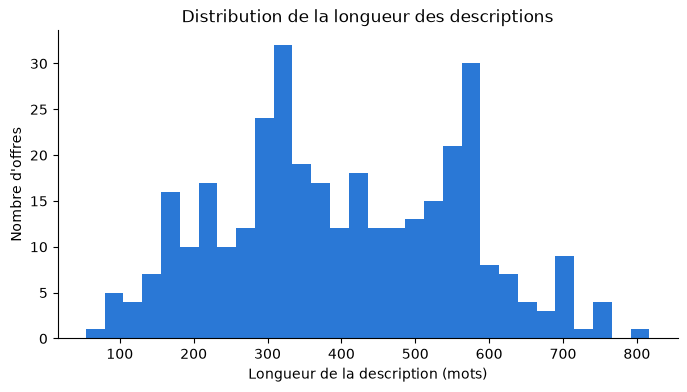

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lengths, bins=30, color=BLUE)
ax.set_xlabel("Longueur de la description (mots)")
ax.set_ylabel("Nombre d'offres")
ax.set_title("Distribution de la longueur des descriptions")
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## Distribution by job title (`intitule`)

Titles are near-free text (e.g. "Développeur Full stack .NET/ Angular Confirmé (H/F)"), so most are unique — worth reporting both the long-tail size and the most frequent exact titles.

In [4]:
title_counts = Counter(o["intitule"] for o in offers)

print(f"intitules uniques: {len(title_counts)} sur {len(offers)} offres")
print(f"intitules apparaissant une seule fois: {sum(1 for c in title_counts.values() if c == 1)}")

intitules uniques: 328 sur 344 offres
intitules apparaissant une seule fois: 317


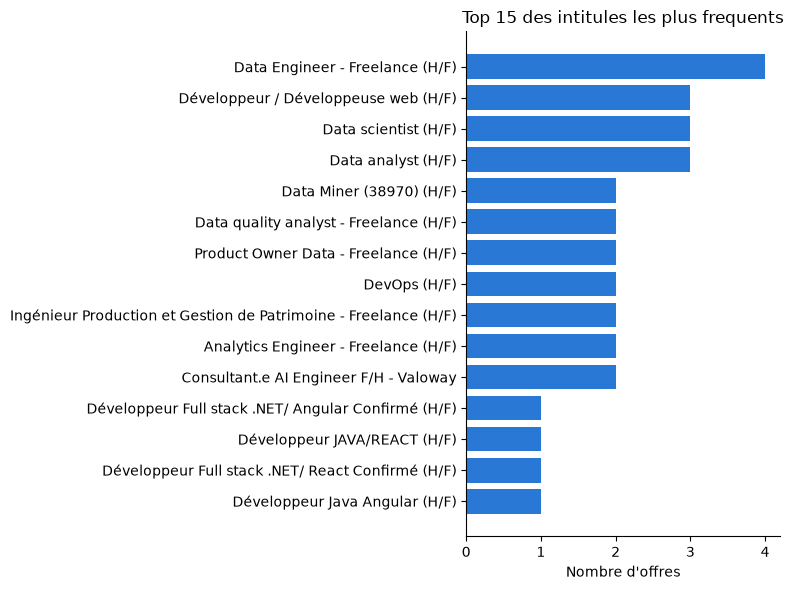

In [5]:
top_titles = title_counts.most_common(15)
labels = [t for t, _ in top_titles][::-1]
counts = [c for _, c in top_titles][::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(labels, counts, color=BLUE)
ax.set_xlabel("Nombre d'offres")
ax.set_title("Top 15 des intitules les plus frequents")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()